In [1]:
# 데이터 처리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 머신러닝
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 모델
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 평가
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [2]:
import os

path = "./data"

files = os.listdir(path)

df_list = []

for file in files:
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(path, file))
        df_list.append(df)

data = pd.concat(df_list, ignore_index=True)

print(data.shape)
data.head()

(2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [3]:
# 기본 데이터 확인

data.info()
data[" Label"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [4]:
# binary classification

data["Label_binary"] = data[" Label"].apply(lambda x: 0 if x == "BENIGN" else 1)

data["Label_binary"].value_counts()

Label_binary
0    2273097
1     557646
Name: count, dtype: int64

In [6]:
for col in data.columns:
    print(col)

 Destination Port
 Flow Duration
 Total Fwd Packets
 Total Backward Packets
Total Length of Fwd Packets
 Total Length of Bwd Packets
 Fwd Packet Length Max
 Fwd Packet Length Min
 Fwd Packet Length Mean
 Fwd Packet Length Std
Bwd Packet Length Max
 Bwd Packet Length Min
 Bwd Packet Length Mean
 Bwd Packet Length Std
Flow Bytes/s
 Flow Packets/s
 Flow IAT Mean
 Flow IAT Std
 Flow IAT Max
 Flow IAT Min
Fwd IAT Total
 Fwd IAT Mean
 Fwd IAT Std
 Fwd IAT Max
 Fwd IAT Min
Bwd IAT Total
 Bwd IAT Mean
 Bwd IAT Std
 Bwd IAT Max
 Bwd IAT Min
Fwd PSH Flags
 Bwd PSH Flags
 Fwd URG Flags
 Bwd URG Flags
 Fwd Header Length
 Bwd Header Length
Fwd Packets/s
 Bwd Packets/s
 Min Packet Length
 Max Packet Length
 Packet Length Mean
 Packet Length Std
 Packet Length Variance
FIN Flag Count
 SYN Flag Count
 RST Flag Count
 PSH Flag Count
 ACK Flag Count
 URG Flag Count
 CWE Flag Count
 ECE Flag Count
 Down/Up Ratio
 Average Packet Size
 Avg Fwd Segment Size
 Avg Bwd Segment Size
 Fwd Header Length.1
Fwd Avg

In [7]:
# 입력 변수(X)와 타겟 변수(y) 분리
X = data.drop(columns=[" Label", "Label_binary"])
y = data["Label_binary"]

print(X.shape)
print(y.shape)

(2830743, 78)
(2830743,)


In [8]:
# 무한값을 결측치로 바꾸기
X = X.replace([np.inf, -np.inf], np.nan)

# 결측치 개수 확인
print(X.isnull().sum().sum())

5734


In [9]:
# 결측치가 있는 행 제거
valid_idx = X.dropna().index

X = X.loc[valid_idx]
y = y.loc[valid_idx]

print(X.shape)
print(y.shape)

(2827876, 78)
(2827876,)


In [10]:
# Train/Test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2262300, 78)
X_test: (565576, 78)
y_train: (2262300,)
y_test: (565576,)


In [11]:
# logistic regression 용 scailing

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# 6. 모델 1: Logistic Regression

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [13]:
# 7. Logistic Regression 평가

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("=== Logistic Regression ===")
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1-score :", f1_score(y_test, y_pred_log))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_log))

=== Logistic Regression ===
Accuracy : 0.942525849753172
Precision: 0.8598829084731521
Recall   : 0.8457924194374321
F1-score : 0.8527794635820977
ROC-AUC  : 0.9808289895701323


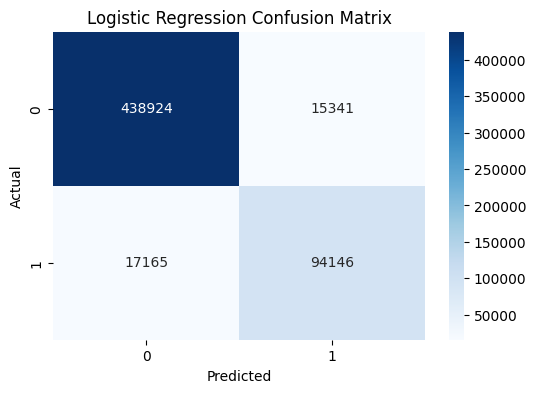

In [14]:
# 8. Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
# 9. 모델 2: Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [16]:
# 10. Random Forest 평가

print("=== Random Forest ===")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_rf))

=== Random Forest ===
Accuracy : 0.9968669109014526
Precision: 0.9959522968677841
Recall   : 0.9880964145502241
F1-score : 0.9920088029439353
ROC-AUC  : 0.999731316574475


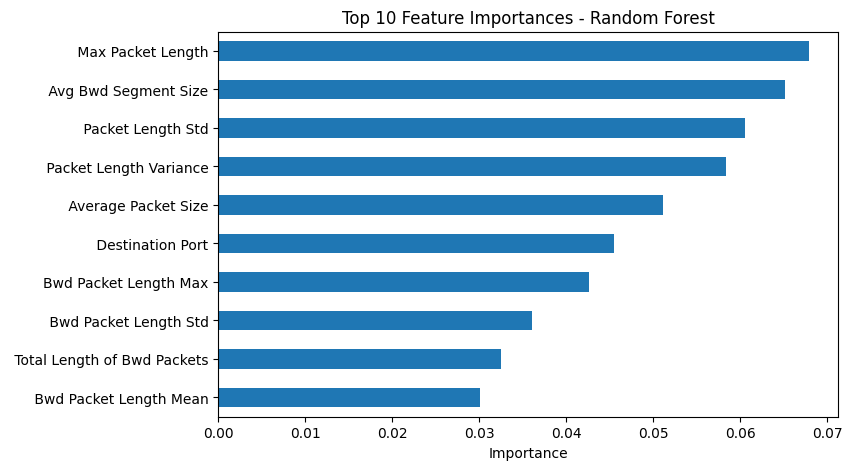

In [17]:
# 11. Random Forest Feature Importance

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
top10_features = feature_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top10_features.sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()

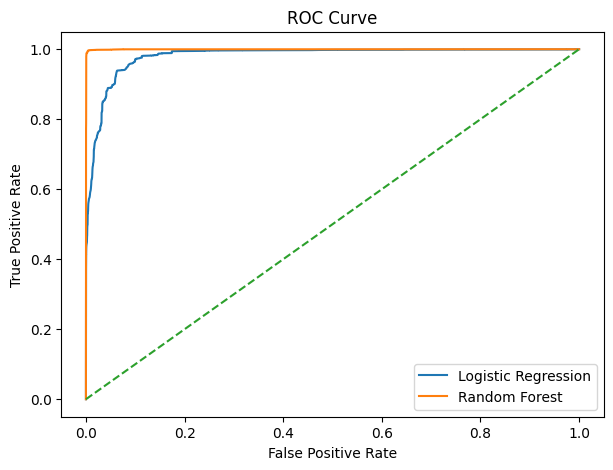

In [18]:
# 12. ROC Curve

from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

---

## 1. 데이터셋 및 분석 목적

본 분석에서는 **CICIDS2017 네트워크 트래픽 데이터셋**을 활용하여 정상 트래픽과 공격 트래픽을 구분하는 **침입 탐지 시스템(Intrusion Detection System)** 문제를 해결하고자 하였다. 

데이터셋에는 네트워크 흐름(flow)에 대한 다양한 통계적 특징(feature)이 포함되어 있으며 각 트래픽은 `Label` 컬럼을 통해 정상(BENIGN) 또는 공격 트래픽으로 구분된다.

본 분석에서는 문제를 단순화하기 위해 정상 트래픽(BENIGN)은 0, 공격 트래픽은 1로 변환하여 **이진 분류(Binary Classification)** 문제로 정의하였다.  

이를 바탕으로 네트워크 트래픽의 여러 수치형 특성을 활용하여 머신러닝 모델을 학습하고 정상 여부를 예측하는 모델을 구축하였다.

모델 학습을 위해 다음과 같은 절차를 수행하였다.

1. 여러 CSV 파일을 하나의 데이터셋으로 병합
2. 라벨을 이진 분류 형태로 변환
3. 무한값 및 결측치 처리
4. Train/Test Split 수행
5. 머신러닝 모델 학습 및 평가

## 2. 모델 선택 이유

본 분석에서는 **Logistic Regression**과 **Random Forest** 두 가지 모델을 사용하였다.

### 2.1 Logistic Regression
Logistic Regression은 대표적인 **선형 분류 모델**로, 구조가 단순하고 해석이 비교적 쉬운 장점이 있다.  
따라서 본 분석에서는 기본적인 기준 성능을 확인하기 위한 **Baseline Model**로 활용하였다.

### 2.2 Random Forest
Random Forest는 여러 개의 결정 트리를 기반으로 예측을 수행하는 **앙상블 모델**이다.  
복잡한 비선형 관계를 잘 학습할 수 있고, 변수 중요도(Feature Importance)를 확인할 수 있어 네트워크 침입 탐지와 같은 문제에 적합하다고 판단하였다.

## 3. Train / Test Split

모델의 일반화 성능을 확인하기 위해 전체 데이터를 학습용과 테스트용으로 분리하였다.  
학습 데이터는 전체의 80%, 테스트 데이터는 20%로 설정하였다.

또한 클래스 비율이 한쪽으로 치우치는 문제를 방지하기 위해 `stratify` 옵션을 사용하여 정상 트래픽과 공격 트래픽의 비율이 학습용 데이터와 테스트용 데이터 모두에서 유사하게 유지되도록 하였다.

## 4. 평가 지표 설명

모델 성능을 비교하기 위해 다음과 같은 평가 지표를 사용하였다.

### 4.1 Accuracy
전체 데이터 중에서 모델이 올바르게 예측한 비율을 의미한다.

### 4.2 Precision
모델이 공격이라고 예측한 데이터 중 실제로 공격인 비율을 의미한다.  
즉, 공격으로 탐지한 결과의 신뢰도를 보여준다.

### 4.3 Recall
실제 공격 데이터 중에서 모델이 공격으로 올바르게 탐지한 비율을 의미한다.  
침입 탐지 문제에서는 실제 공격을 놓치지 않는 것이 중요하므로 Recall이 매우 중요한 지표가 될 수 있다.

### 4.4 F1-score
Precision과 Recall의 조화 평균으로, 두 지표를 균형 있게 반영한 값이다.

### 4.5 ROC-AUC
정상 트래픽과 공격 트래픽을 얼마나 잘 구분하는지를 보여주는 지표로, 값이 1에 가까울수록 모델의 구분 성능이 우수함을 의미한다.

## 5. Logistic Regression 결과 해석

Logistic Regression 모델은 비교적 단순한 선형 분류 모델이기 때문에 데이터의 전반적인 경향을 빠르게 학습할 수 있다.  
실험 결과, 정상 트래픽과 공격 트래픽을 어느 정도 구분하는 성능을 보였으나 일부 공격 패턴은 충분히 반영하지 못하는 한계가 있었다.

Confusion Matrix를 통해 정상 트래픽과 공격 트래픽을 전반적으로 잘 분류했는지 확인할 수 있었으며, 일부 공격 트래픽을 정상으로 분류하는 경우도 존재하였다.  
이는 네트워크 트래픽 데이터가 단순한 선형 구조보다 더 복잡한 패턴을 포함하고 있기 때문으로 해석할 수 있다.

따라서 Logistic Regression은 기준 모델로서는 의미가 있지만, 보다 높은 탐지 성능을 위해서는 비선형 구조를 잘 반영하는 모델이 필요하다고 볼 수 있다.

## 6. Random Forest 결과 해석

Random Forest 모델은 여러 개의 결정 트리를 기반으로 예측을 수행하기 때문에 복잡한 데이터 구조와 비선형 관계를 효과적으로 학습할 수 있다.  
실험 결과, Accuracy, Precision, Recall, F1-score, ROC-AUC 등 대부분의 지표에서 Logistic Regression보다 더 우수한 성능을 보였다.

이는 네트워크 트래픽 데이터가 다양한 특징 간 복합적인 관계를 가지기 때문이며, Random Forest가 이러한 패턴을 더 잘 반영했기 때문으로 해석할 수 있다.  
특히 침입 탐지와 같이 단순 선형 경계로 구분하기 어려운 문제에서는 Random Forest와 같은 트리 기반 모델이 더 적합한 경우가 많다.

## 7. Feature Importance 분석

Random Forest 모델은 각 Feature가 예측에 얼마나 기여했는지를 수치로 확인할 수 있다는 장점이 있다.  
Feature Importance 그래프를 통해 공격 탐지에 큰 영향을 미치는 주요 변수를 확인하였다.

중요도가 높은 변수들은 주로 패킷 길이, 패킷 수, 흐름 지속 시간, 전송 속도 등 네트워크 흐름의 통계적 특성과 관련된 변수들이었다.  
이를 통해 침입 탐지에서는 단순히 하나의 패킷 정보보다 전체 흐름에서 나타나는 패턴과 통계량이 중요한 역할을 한다는 점을 확인할 수 있었다.

## 8. 모델 비교 분석

두 모델을 비교한 결과, **Random Forest가 Logistic Regression보다 전반적으로 더 우수한 성능**을 보였다.

Logistic Regression은 구조가 단순하고 해석이 쉽다는 장점이 있지만, 데이터가 복잡한 비선형 관계를 가질 경우 한계가 있다.  
반면 Random Forest는 다양한 분기 구조를 통해 복잡한 패턴을 학습할 수 있어 네트워크 공격 탐지 문제에서 더 적합한 성능을 보였다.

따라서 본 분석에서는 Random Forest를 더 적절한 모델로 판단하였다.

## 9. 최종 결론

본 분석에서는 CICIDS2017 데이터셋을 활용하여 정상 트래픽과 공격 트래픽을 구분하는 이진 분류 문제를 수행하였다.  
이를 위해 Logistic Regression과 Random Forest 모델을 학습하고 다양한 평가 지표를 통해 성능을 비교하였다.

그 결과, Random Forest 모델이 Logistic Regression보다 더 높은 성능을 보였으며, 이는 네트워크 트래픽 데이터가 복잡한 비선형 패턴을 포함하고 있기 때문으로 해석할 수 있다.  
또한 Feature Importance 분석을 통해 네트워크 흐름 관련 통계적 특징들이 침입 탐지에 중요한 역할을 한다는 점도 확인할 수 있었다.

향후에는 XGBoost와 같은 고성능 모델을 추가로 적용하거나, 공격 유형별 다중 분류 문제로 확장하여 보다 정교한 침입 탐지 분석을 수행할 수 있을 것으로 보인다.

### Logistic Regression 선택 이유
Logistic Regression은 가장 기본적인 분류 모델로, 기준 성능을 확인하기에 적합하다고 판단하여 사용하였다. 또한 구조가 단순하여 결과 해석이 비교적 쉽다는 장점이 있다.

### Random Forest 선택 이유
Random Forest는 비선형적인 데이터 패턴을 잘 반영할 수 있는 트리 기반 앙상블 모델이다. 네트워크 트래픽 데이터처럼 복잡한 특징 관계를 가지는 문제에서 더 높은 성능을 기대할 수 있어 사용하였다.

### 하이퍼파라미터 설정 이유
Logistic Regression은 학습 반복 횟수 부족으로 인한 수렴 문제를 방지하기 위해 `max_iter=1000`으로 설정하였다.  
Random Forest는 기본적인 성능 비교를 위해 `n_estimators=100`으로 설정하였고, 과적합을 일부 방지하기 위해 `max_depth=10`을 적용하였다.

### 결과 해석
실험 결과, Random Forest 모델이 Logistic Regression보다 더 우수한 성능을 보였다. 이는 네트워크 트래픽 데이터가 단순한 선형 관계보다 복잡한 비선형 패턴을 가지기 때문으로 해석할 수 있다.